In [11]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



=====  Electricity (Polynomial LSE)  =====
MAE : 95.48877997722259
RMSE: 117.7771098726855
R²  : 0.700505555595343

=====  Natural Gas (Polynomial LSE)  =====
MAE : 1.5017523227125131
RMSE: 1.8659096366344858
R²  : 0.9147251670981484


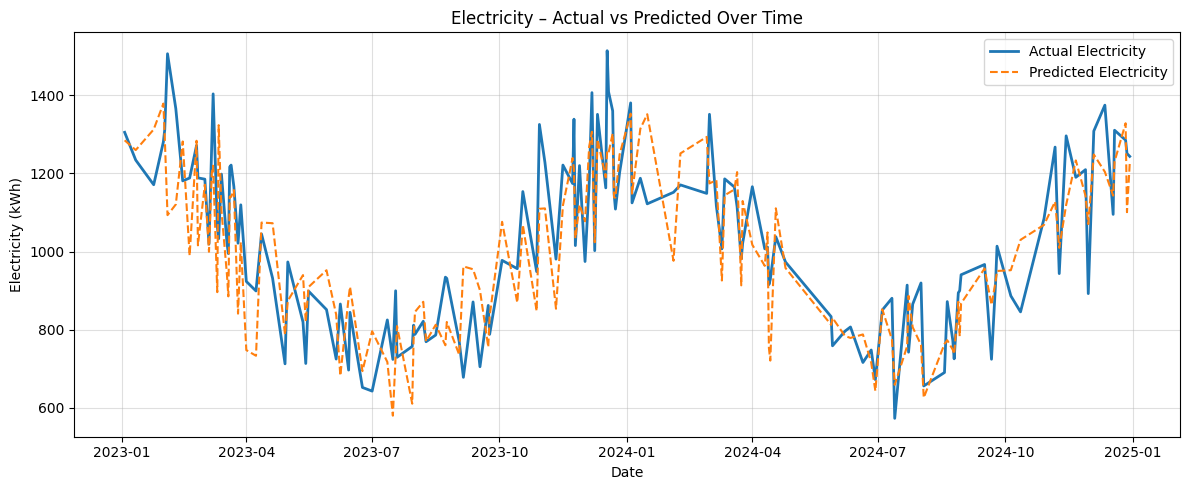


===== ELECTRICITY — Actual vs Predicted =====
    Actual (kWh)  Predicted (kWh)
0        1308.00      1247.986473
1        1505.64      1093.007924
2         948.65       847.885276
3        1165.70      1017.193389
4        1013.66       950.260651
5         880.56       775.034498
6        1365.33      1120.429896
7        1148.72      1137.908439
8         573.52       659.132855
9         758.95       830.443828
10       1243.20      1225.900501
11       1359.55      1301.867572
12        696.91       882.360419
13       1209.32      1142.534151
14       1403.00      1219.441581
15       1216.28      1140.763883
16       1197.96      1105.632705
17        886.57       952.281928
18        643.18       796.128475
19       1121.93      1351.053958


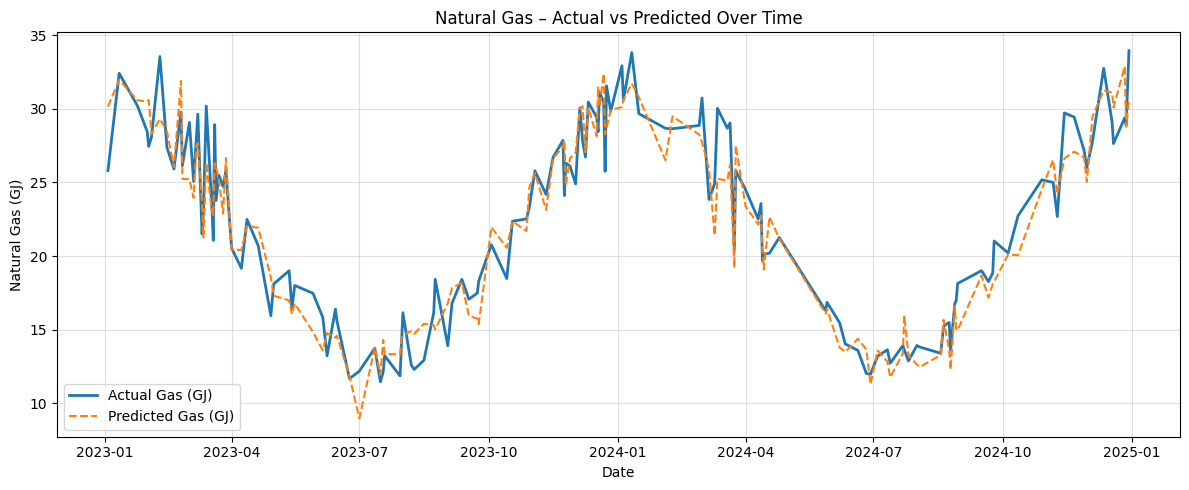


===== NATURAL GAS — Actual vs Predicted =====
    Actual (GJ)  Predicted (GJ)
0        27.766       29.465671
1        28.075       28.298355
2        22.520       21.703009
3        24.511       23.381281
4        21.023       18.249434
5        13.631       12.832263
6        33.557       29.318706
7        25.753       28.267410
8        12.713       11.755368
9        16.849       16.401951
10       33.953       30.646764
11       30.434       32.391452
12       16.391       14.452483
13       27.185       26.699751
14       29.642       27.663643
15       28.930       26.311845
16       30.192       26.358580
17       20.204       20.110080
18       12.178        8.970512
19       29.678       30.808169


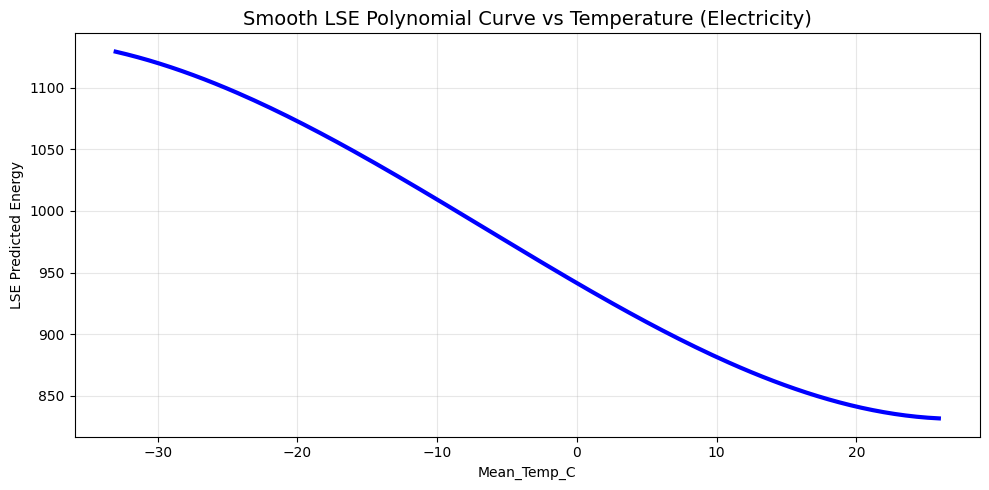

In [10]:
#LSE cubic equation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.graph_objects as go

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')
# Keep date for plotting
df['Date_original'] = df['Date']

# ----------------------------------------------------
# TIME-BASED FEATURES
# ----------------------------------------------------
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# ----------------------------------------------------
# FEATURE SETS
# ----------------------------------------------------
features_energy = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day','relative_humidity',
    'CDD_18', 'month', 'day_of_week', 'is_weekend'
]

features_gas = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day','relative_humidity',
    'HDD_18', 'month', 'day_of_week', 'is_weekend'
]

X_energy = df[features_energy]
y_energy = df['site_energy_kwh_daily']
dates_energy = df['Date_original']

X_gas = df[features_gas]
y_gas = df['Natural_Gas_Use_GJ']
dates_gas = df['Date_original']

# ----------------------------------------------------
# TRAIN/TEST SPLIT
# ----------------------------------------------------
X_train_e, X_test_e, y_train_e, y_test_e, dates_train_e, dates_test_e = train_test_split(
    X_energy, y_energy, dates_energy, test_size=0.2, random_state=42
)

X_train_g, X_test_g, y_train_g, y_test_g, dates_train_g, dates_test_g = train_test_split(
    X_gas, y_gas, dates_gas, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# FIXED POLYNOMIAL LSE USING PSEUDOINVERSE
# ----------------------------------------------------
def polynomial_lse_fit(X_train, y_train, degree=3):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X_train)

    # pseudoinverse avoids singular matrix errors
    beta = np.linalg.pinv(X_poly.T @ X_poly) @ (X_poly.T @ y_train)

    return beta, poly

def polynomial_predict(beta, poly, X):
    X_poly = poly.transform(X)
    return X_poly @ beta

# ----------------------------------------------------
# TRAIN MODELS
# ----------------------------------------------------
beta_energy, poly_energy = polynomial_lse_fit(X_train_e, y_train_e, degree=3)
beta_gas, poly_gas = polynomial_lse_fit(X_train_g, y_train_g, degree=3)

pred_energy = polynomial_predict(beta_energy, poly_energy, X_test_e)
pred_gas = polynomial_predict(beta_gas, poly_gas, X_test_g)

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
def metrics(name, y_true, y_pred):
    print("\n===== ", name, " =====")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))

metrics("Electricity (Polynomial LSE)", y_test_e, pred_energy)
metrics("Natural Gas (Polynomial LSE)", y_test_g, pred_gas)

# ----------------------------------------------------
# TIME-SERIES PLOTS
# ----------------------------------------------------
def plot_electricity_time_series(dates, actual, predicted):
    df_plot = pd.DataFrame({
        "Date": dates,
        "Actual": actual,
        "Predicted": predicted
    }).sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.plot(df_plot["Date"], df_plot["Actual"], label="Actual Electricity", linewidth=2)
    plt.plot(df_plot["Date"], df_plot["Predicted"], label="Predicted Electricity", linestyle="--")
    plt.title("Electricity – Actual vs Predicted Over Time")
    plt.xlabel("Date")
    plt.ylabel("Electricity (kWh)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_gas_time_series(dates, actual, predicted):
    df_plot = pd.DataFrame({
        "Date": dates,
        "Actual": actual,
        "Predicted": predicted
    }).sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.plot(df_plot["Date"], df_plot["Actual"], label="Actual Gas (GJ)", linewidth=2)
    plt.plot(df_plot["Date"], df_plot["Predicted"], label="Predicted Gas (GJ)", linestyle="--")
    plt.title("Natural Gas – Actual vs Predicted Over Time")
    plt.xlabel("Date")
    plt.ylabel("Natural Gas (GJ)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------
# PRINT TABLES
# ----------------------------------------------------
def print_actual_predicted_electricity(actual, predicted, n=20):
    print("\n===== ELECTRICITY — Actual vs Predicted =====")
    df_print = pd.DataFrame({"Actual (kWh)": actual.values, "Predicted (kWh)": predicted})
    print(df_print.head(n).to_string())

def print_actual_predicted_gas(actual, predicted, n=20):
    print("\n===== NATURAL GAS — Actual vs Predicted =====")
    df_print = pd.DataFrame({"Actual (GJ)": actual.values, "Predicted (GJ)": predicted})
    print(df_print.head(n).to_string())

# ----------------------------------------------------
# DYNAMIC 3D PLOT — ELECTRICITY
# ----------------------------------------------------
def plot_3d_dynamic_electricity(X_test, actual, predicted):
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=X_test['Mean_Temp_C'],
        y=X_test['visitors_per_day'],
        z=actual,
        mode='markers',
        marker=dict(size=4, color='blue'),
        name='Actual Electricity'
    ))

    fig.add_trace(go.Scatter3d(
        x=X_test['Mean_Temp_C'],
        y=X_test['visitors_per_day'],
        z=predicted,
        mode='markers',
        marker=dict(size=4, color='red'),
        name='Predicted Electricity'
    ))

    fig.update_layout(
        title="Dynamic 3D Plot — Electricity (Actual vs Predicted)",
        scene=dict(
            xaxis_title="Mean Temp (°C)",
            yaxis_title="Visitors per Day",
            zaxis_title="Electricity (kWh)"
        ),
        height=700
    )

    fig.show()

# ----------------------------------------------------
# DYNAMIC 3D PLOT — NATURAL GAS
# ----------------------------------------------------
def plot_3d_dynamic_gas(X_test, actual, predicted):
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=X_test['Mean_Temp_C'],
        y=X_test['visitors_per_day'],
        z=actual,
        mode='markers',
        marker=dict(size=4, color='blue'),
        name='Actual Gas Use'
    ))

    fig.add_trace(go.Scatter3d(
        x=X_test['Mean_Temp_C'],
        y=X_test['visitors_per_day'],
        z=predicted,
        mode='markers',
        marker=dict(size=4, color='red'),
        name='Predicted Gas Use'
    ))

    fig.update_layout(
        title="Dynamic 3D Plot — Natural Gas (Actual vs Predicted)",
        scene=dict(
            xaxis_title="Mean Temp (°C)",
            yaxis_title="Visitors per Day",
            zaxis_title="Natural Gas (GJ)"
        ),
        height=700
    )

    fig.show()

# ----------------------------------------------------
# RUN EVERYTHING
# ----------------------------------------------------
plot_electricity_time_series(dates_test_e, y_test_e, pred_energy)
print_actual_predicted_electricity(y_test_e, pred_energy)

plot_gas_time_series(dates_test_g, y_test_g, pred_gas)
print_actual_predicted_gas(y_test_g, pred_gas)

plot_3d_dynamic_electricity(X_test_e, y_test_e, pred_energy)
plot_3d_dynamic_gas(X_test_g, y_test_g, pred_gas)



# ===========================================================
# PLOT SMOOTH LSE CURVE (1 FEATURE VARIES, OTHERS FIXED)
# ===========================================================

def plot_lse_smooth_curve(beta, poly, X, feature_to_plot, title):
    # Generate smooth range for the selected feature
    x_min = X[feature_to_plot].min()
    x_max = X[feature_to_plot].max()
    x_smooth = np.linspace(x_min, x_max, 150)

    # Build a template row of feature means
    base = X.mean().to_dict()

    # Build evaluation dataset
    smooth_df = pd.DataFrame([base for _ in range(len(x_smooth))])
    smooth_df[feature_to_plot] = x_smooth

    # Build polynomial features
    X_poly = poly.transform(smooth_df)

    # Predict using LSE coefficients
    y_smooth = X_poly @ beta

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(x_smooth, y_smooth, linewidth=3, color="blue")
    plt.title(title, fontsize=14)
    plt.xlabel(feature_to_plot)
    plt.ylabel("LSE Predicted Energy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# EXAMPLE PLOT FOR ELECTRICITY LSE:
plot_lse_smooth_curve(
    beta_energy,
    poly_energy,
    X_train_e,
    feature_to_plot="Mean_Temp_C",
    title="Smooth LSE Polynomial Curve vs Temperature (Electricity)"
)






===== Electricity – Random Forest =====
MAE : 77.7099209790987
RMSE: 98.95787991345752
R²  : 0.788569445202128

===== Natural Gas – Random Forest =====
MAE : 1.4967558530749512
RMSE: 1.877021969960537
R²  : 0.9137064424519165


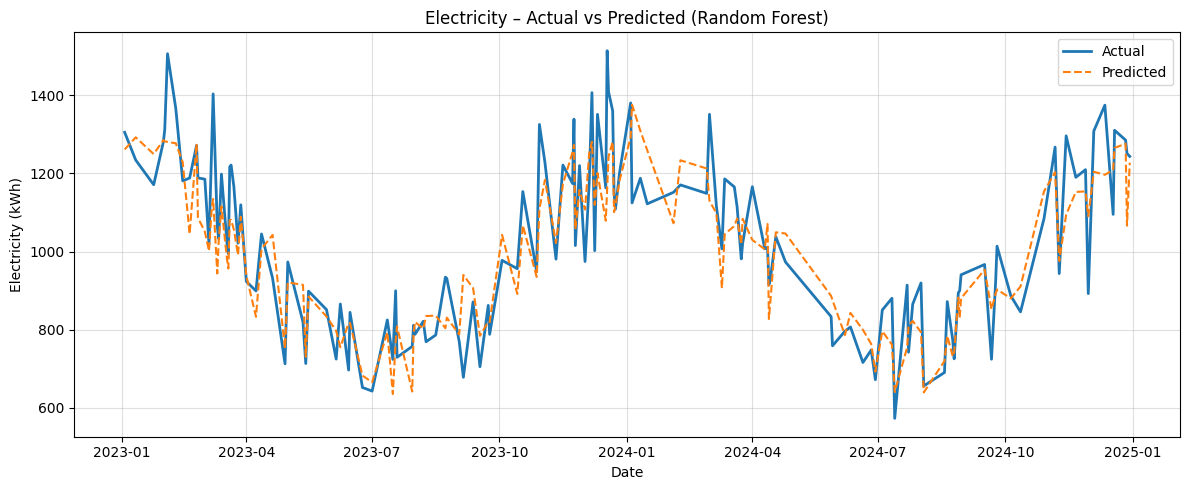

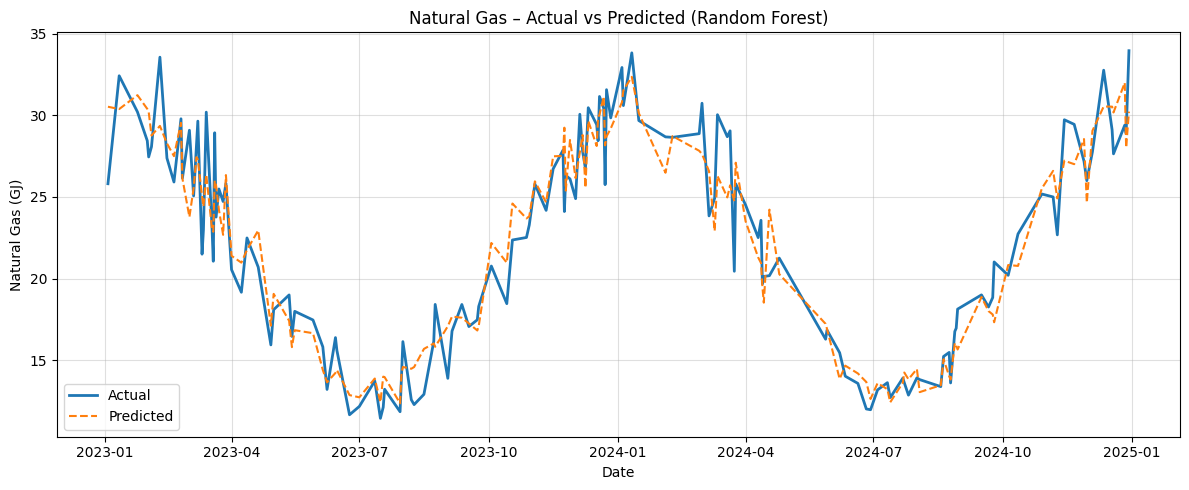


===== Electricity — Actual vs Predicted =====
     Actual    Predicted
0   1308.00  1203.833233
1   1505.64  1280.350833
2    948.65   935.231267
3   1165.70  1029.629928
4   1013.66   903.056433
5    880.56   762.031859
6   1365.33  1276.762142
7   1148.72  1100.723694
8    573.52   640.963320
9    758.95   875.509117
10  1243.20  1227.244780
11  1359.55  1280.726733
12   696.91   817.248058
13  1209.32  1153.662522
14  1403.00  1134.463707
15  1216.28  1080.458959
16  1197.96  1115.576807
17   886.57   880.111100
18   643.18   665.936851
19  1121.93  1258.881673

===== Natural Gas — Actual vs Predicted =====
    Actual  Predicted
0   27.766  29.052756
1   28.075  28.760731
2   22.520  23.686147
3   24.511  23.519855
4   21.023  17.329450
5   13.631  13.229572
6   33.557  29.350211
7   25.753  28.160153
8   12.713  12.429140
9   16.849  16.925775
10  33.953  30.226268
11  30.434  31.144080
12  16.391  14.230278
13  27.185  28.546840
14  29.642  27.302249
15  28.930  26.000680
16  30.

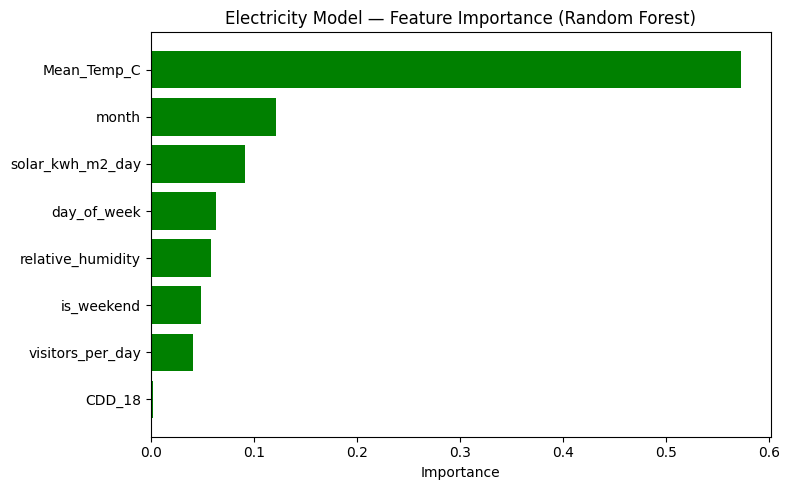

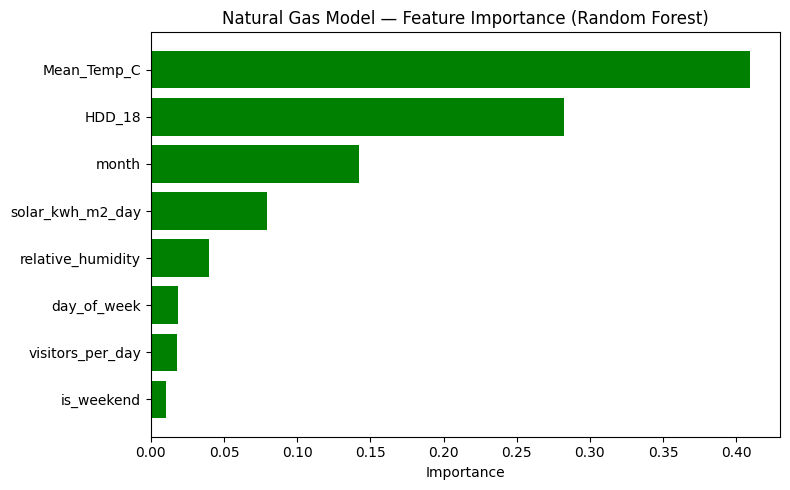

In [12]:
# RANDOM FOREST

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')

# Preserve date for plotting
df["Date_original"] = df["Date"]

# ----------------------------------------------------
# TIME-BASED FEATURES
# ----------------------------------------------------
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# DO NOT DROP DATE (we need it for plotting later)

# ----------------------------------------------------
# FEATURE SETS
# ----------------------------------------------------
features_energy = [
    "Mean_Temp_C", "visitors_per_day", "solar_kwh_m2_day", 'relative_humidity',
    "CDD_18", "month", "day_of_week", "is_weekend"
]

features_gas = [
    "Mean_Temp_C", "visitors_per_day", "solar_kwh_m2_day",'relative_humidity',
    "HDD_18", "month", "day_of_week", "is_weekend"
]

X_energy = df[features_energy]
y_energy = df["site_energy_kwh_daily"]
dates_energy = df["Date_original"]

X_gas = df[features_gas]
y_gas = df["Natural_Gas_Use_GJ"]
dates_gas = df["Date_original"]

# ----------------------------------------------------
# TRAIN/TEST SPLIT
# ----------------------------------------------------
X_train_e, X_test_e, y_train_e, y_test_e, dates_train_e, dates_test_e = train_test_split(
    X_energy, y_energy, dates_energy, test_size=0.2, random_state=42
)

X_train_g, X_test_g, y_train_g, y_test_g, dates_train_g, dates_test_g = train_test_split(
    X_gas, y_gas, dates_gas, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# TRAIN RANDOM FOREST MODELS
# ----------------------------------------------------
rf_energy = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_energy.fit(X_train_e, y_train_e)
pred_energy = rf_energy.predict(X_test_e)

rf_gas = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_gas.fit(X_train_g, y_train_g)
pred_gas = rf_gas.predict(X_test_g)

# ----------------------------------------------------
# METRICS FUNCTION
# ----------------------------------------------------
def metrics(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))

metrics("Electricity – Random Forest", y_test_e, pred_energy)
metrics("Natural Gas – Random Forest", y_test_g, pred_gas)

# ----------------------------------------------------
# TIME SERIES PLOTTING FUNCTION
# ----------------------------------------------------
def plot_time_series(dates, actual, predicted, title, ylabel):
    df_plot = pd.DataFrame({
        "Date": dates,
        "Actual": actual,
        "Predicted": predicted
    }).sort_values("Date")

    plt.figure(figsize=(12,5))
    plt.plot(df_plot["Date"], df_plot["Actual"], label="Actual", linewidth=2)
    plt.plot(df_plot["Date"], df_plot["Predicted"], label="Predicted", linestyle="--")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ELECTRICITY TIME SERIES
plot_time_series(
    dates_test_e, y_test_e, pred_energy,
    "Electricity – Actual vs Predicted (Random Forest)",
    "Electricity (kWh)"
)

# NATURAL GAS TIME SERIES
plot_time_series(
    dates_test_g, y_test_g, pred_gas,
    "Natural Gas – Actual vs Predicted (Random Forest)",
    "Natural Gas (GJ)"
)

# ----------------------------------------------------
# PRINT ACTUAL VS PREDICTED TABLES
# ----------------------------------------------------
def print_actual_predicted(name, actual, predicted, n=20):
    print(f"\n===== {name} — Actual vs Predicted =====")
    df_print = pd.DataFrame({"Actual": actual.values, "Predicted": predicted})
    print(df_print.head(n).to_string(index=True))

print_actual_predicted("Electricity", y_test_e, pred_energy)
print_actual_predicted("Natural Gas", y_test_g, pred_gas)

# ----------------------------------------------------
# FEATURE IMPORTANCE PLOTS
# ----------------------------------------------------
def plot_rf_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)

    plt.figure(figsize=(8,5))
    plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx], color='green')
    plt.title(title + " — Feature Importance (Random Forest)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# ELECTRICITY FEATURE IMPORTANCE
plot_rf_feature_importance(
    rf_energy, features_energy,
    "Electricity Model"
)

# NATURAL GAS FEATURE IMPORTANCE
plot_rf_feature_importance(
    rf_gas, features_gas,
    "Natural Gas Model"
)




===== MODEL METRICS COMPARISON =====

Electricity_LSE:
  MAE: 95.48877997722259
  RMSE: 117.7771098726855
  R2: 0.700505555595343

Electricity_RF:
  MAE: 77.7099209790987
  RMSE: 98.95787991345752
  R2: 0.788569445202128

Gas_LSE:
  MAE: 1.5017523227125131
  RMSE: 1.8659096366344858
  R2: 0.9147251670981484

Gas_RF:
  MAE: 1.4967558530749512
  RMSE: 1.877021969960537
  R2: 0.9137064424519165


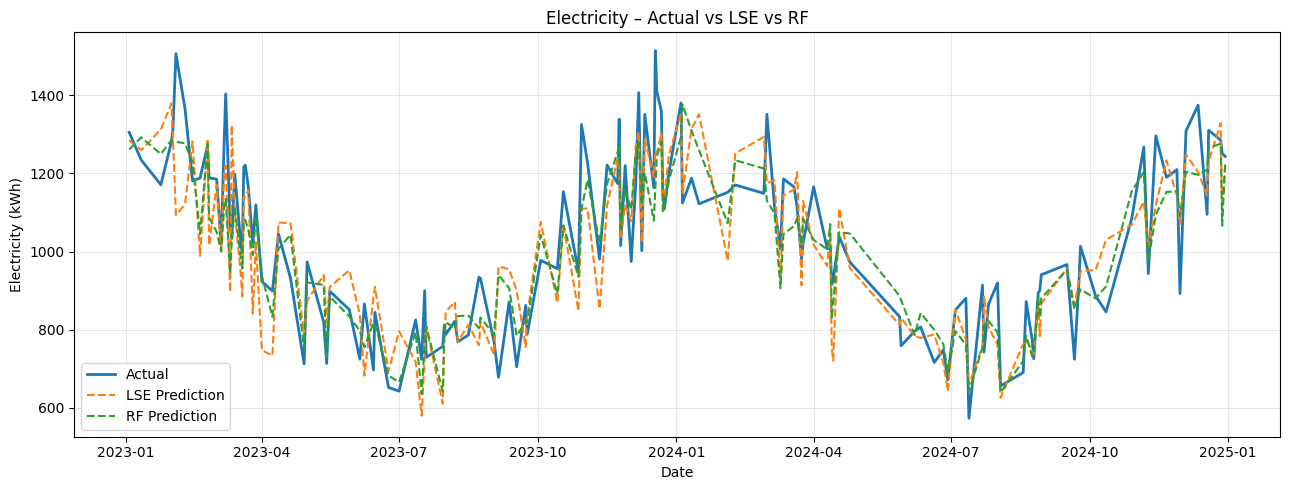

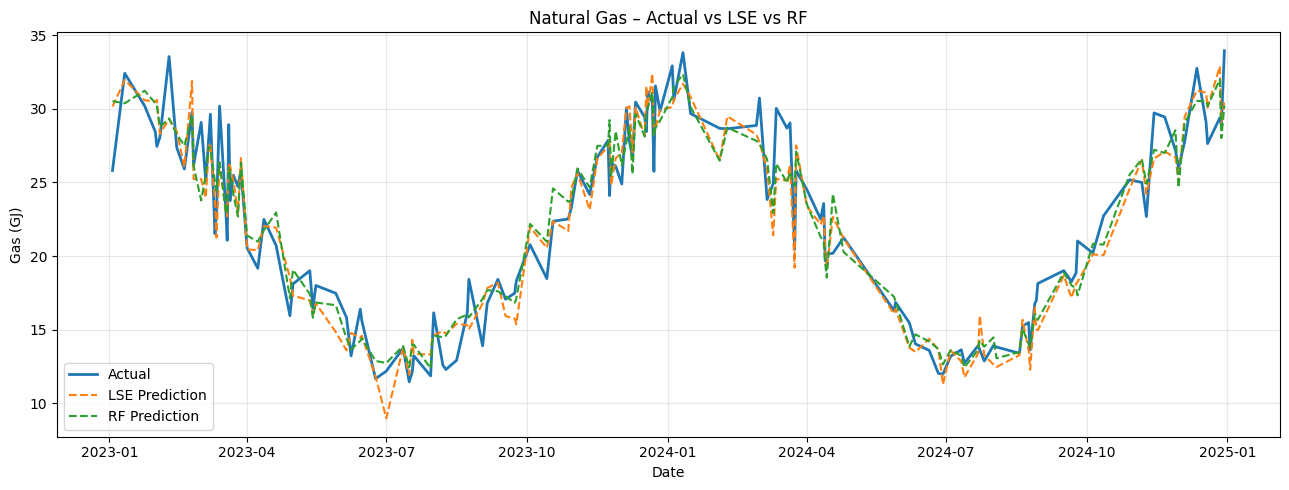

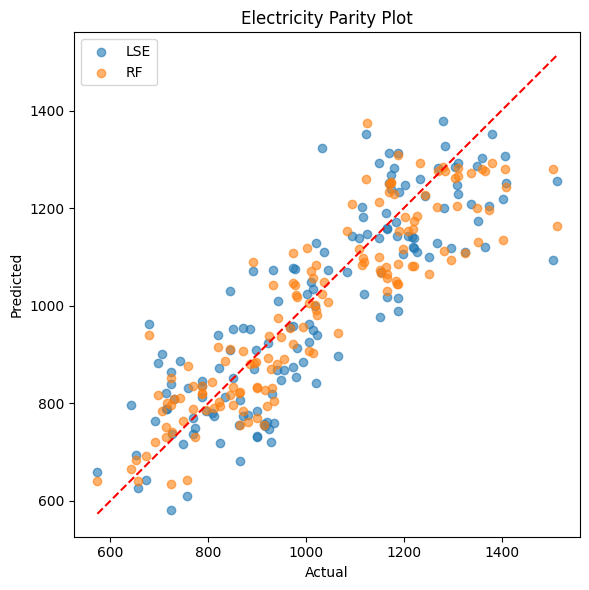

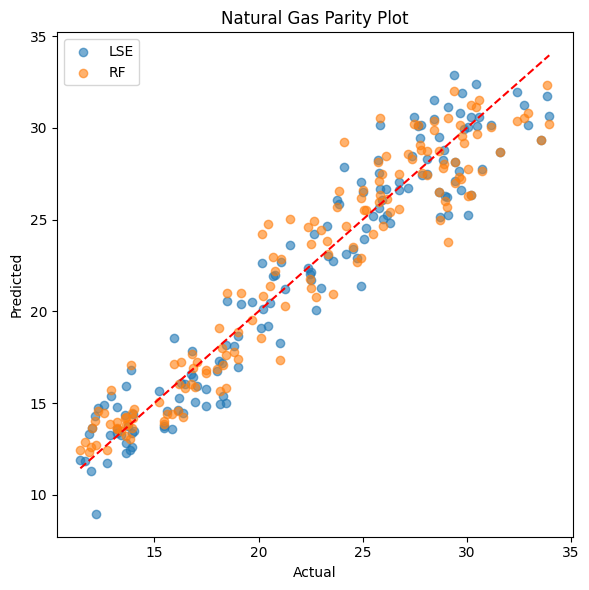

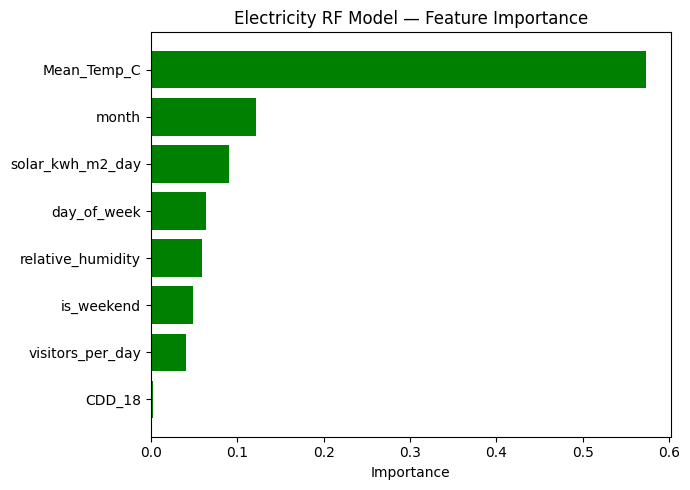

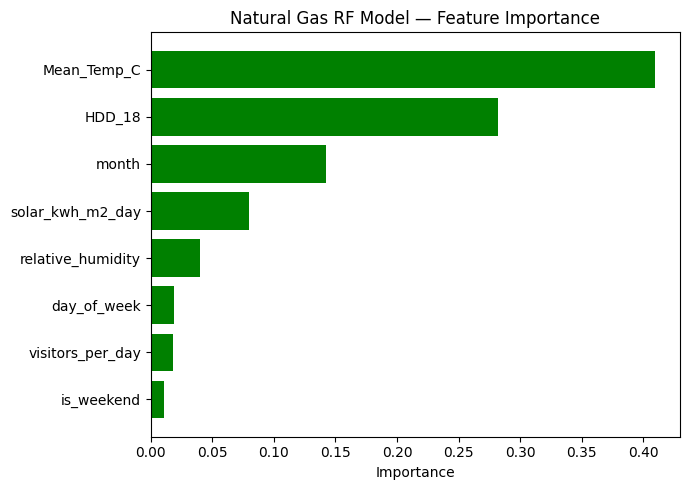

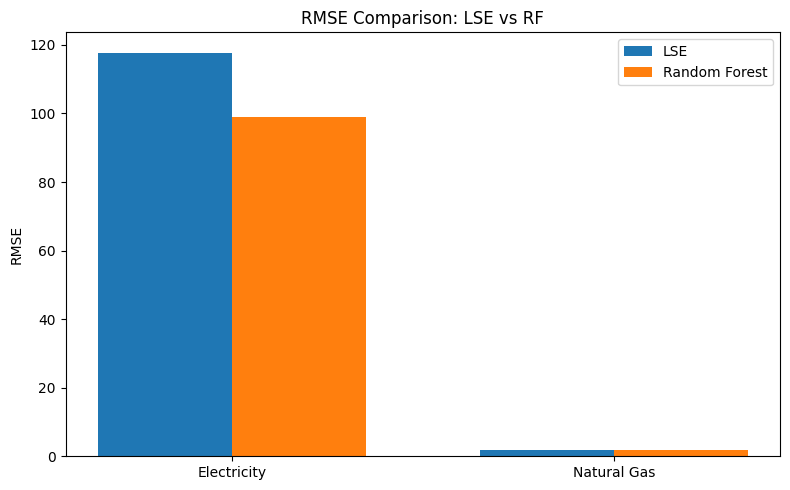

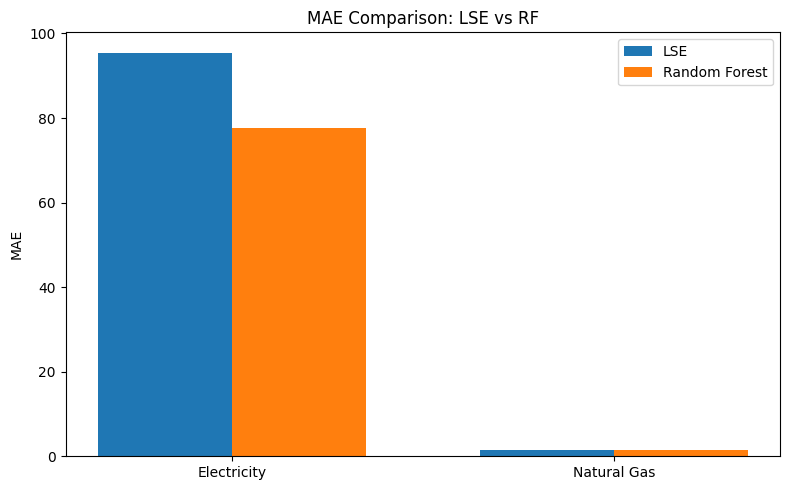

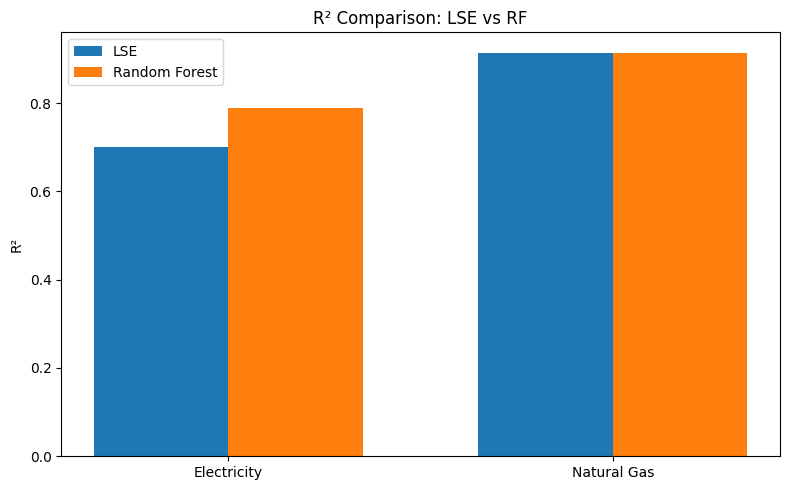

In [13]:
#COMPARING RANDOM FOREST AND LSE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')

# Keep date for plots
df['Date_original'] = df['Date']

# ---------------------------------------------------------
# TIME-BASED FEATURES
# ---------------------------------------------------------
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# ---------------------------------------------------------
# FEATURE SETS
# ---------------------------------------------------------
features_energy = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day','relative_humidity',
    'CDD_18', 'month', 'day_of_week', 'is_weekend'
]

features_gas = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day','relative_humidity',
    'HDD_18', 'month', 'day_of_week', 'is_weekend'
]

X_energy = df[features_energy]
y_energy = df['site_energy_kwh_daily']
dates_energy = df['Date_original']

X_gas = df[features_gas]
y_gas = df['Natural_Gas_Use_GJ']
dates_gas = df['Date_original']

# ---------------------------------------------------------
# TRAIN/TEST SPLIT
# ---------------------------------------------------------
def split(X, y, dates):
    return train_test_split(X, y, dates, test_size=0.2, random_state=42)

X_train_e, X_test_e, y_train_e, y_test_e, dates_train_e, dates_test_e = split(X_energy, y_energy, dates_energy)
X_train_g, X_test_g, y_train_g, y_test_g, dates_train_g, dates_test_g = split(X_gas, y_gas, dates_gas)

# ---------------------------------------------------------
# LSE POLYNOMIAL REGRESSION (degree=3)
# ---------------------------------------------------------
def lse_fit(X_train, y_train, degree=3):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X_train)
    beta = np.linalg.pinv(X_poly.T @ X_poly) @ (X_poly.T @ y_train)
    return beta, poly

def lse_predict(beta, poly, X):
    return poly.transform(X) @ beta

# Train LSE models
beta_energy, poly_energy = lse_fit(X_train_e, y_train_e)
beta_gas, poly_gas = lse_fit(X_train_g, y_train_g)

# Predict with LSE
lse_pred_energy = lse_predict(beta_energy, poly_energy, X_test_e)
lse_pred_gas = lse_predict(beta_gas, poly_gas, X_test_g)

# ---------------------------------------------------------
# RANDOM FOREST MODELS
# ---------------------------------------------------------
rf_energy = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_energy.fit(X_train_e, y_train_e)
rf_pred_energy = rf_energy.predict(X_test_e)

rf_gas = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_gas.fit(X_train_g, y_train_g)
rf_pred_gas = rf_gas.predict(X_test_g)

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = {
    "Electricity_LSE": evaluate(y_test_e, lse_pred_energy),
    "Electricity_RF": evaluate(y_test_e, rf_pred_energy),
    "Gas_LSE": evaluate(y_test_g, lse_pred_gas),
    "Gas_RF": evaluate(y_test_g, rf_pred_gas),
}

print("\n\n===== MODEL METRICS COMPARISON =====")
for name, m in results.items():
    print(f"\n{name}:")
    for k, v in m.items():
        print(f"  {k}: {v}")

# ---------------------------------------------------------
# TIME-SERIES PLOTS
# ---------------------------------------------------------
def plot_time_series(dates, actual, pred1, pred2, label1, label2, title, ylabel):
    df_plot = pd.DataFrame({
        "Date": dates,
        "Actual": actual,
        label1: pred1,
        label2: pred2
    }).sort_values("Date")

    plt.figure(figsize=(13,5))
    plt.plot(df_plot["Date"], df_plot["Actual"], label="Actual", linewidth=2)
    plt.plot(df_plot["Date"], df_plot[label1], "--", label=label1)
    plt.plot(df_plot["Date"], df_plot[label2], "--", label=label2)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_time_series(dates_test_e, y_test_e, lse_pred_energy, rf_pred_energy,
                 "LSE Prediction", "RF Prediction",
                 "Electricity – Actual vs LSE vs RF", "Electricity (kWh)")

plot_time_series(dates_test_g, y_test_g, lse_pred_gas, rf_pred_gas,
                 "LSE Prediction", "RF Prediction",
                 "Natural Gas – Actual vs LSE vs RF", "Gas (GJ)")

# ---------------------------------------------------------
# PARITY PLOTS (Actual vs Predicted)
# ---------------------------------------------------------
def parity_plot(y_true, pred1, pred2, model1, model2, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, pred1, alpha=0.6, label=model1)
    plt.scatter(y_true, pred2, alpha=0.6, label=model2)
    diag = [y_true.min(), y_true.max()]
    plt.plot(diag, diag, "r--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

parity_plot(y_test_e, lse_pred_energy, rf_pred_energy,
            "LSE", "RF", "Electricity Parity Plot")

parity_plot(y_test_g, lse_pred_gas, rf_pred_gas,
            "LSE", "RF", "Natural Gas Parity Plot")

# ---------------------------------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------
def plot_feature_importance(model, features, title):
    importances = model.feature_importances_
    idx = np.argsort(importances)

    plt.figure(figsize=(7,5))
    plt.barh(np.array(features)[idx], importances[idx], color="green")
    plt.title(title + " — Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf_energy, features_energy, "Electricity RF Model")
plot_feature_importance(rf_gas, features_gas, "Natural Gas RF Model")

# ---------------------------------------------------------
# METRIC COMPARISON BAR CHARTS
# ---------------------------------------------------------
def metric_compare_plot(metric_name, lse_val_e, rf_val_e, lse_val_g, rf_val_g):
    labels = ["Electricity", "Natural Gas"]
    lse_vals = [lse_val_e, lse_val_g]
    rf_vals = [rf_val_e, rf_val_g]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, lse_vals, width, label="LSE")
    plt.bar(x + width/2, rf_vals, width, label="Random Forest")

    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison: LSE vs RF")
    plt.xticks(x, labels)
    plt.legend()
    plt.tight_layout()
    plt.show()

metric_compare_plot(
    "RMSE",
    results["Electricity_LSE"]["RMSE"], results["Electricity_RF"]["RMSE"],
    results["Gas_LSE"]["RMSE"], results["Gas_RF"]["RMSE"]
)

metric_compare_plot(
    "MAE",
    results["Electricity_LSE"]["MAE"], results["Electricity_RF"]["MAE"],
    results["Gas_LSE"]["MAE"], results["Gas_RF"]["MAE"]
)

metric_compare_plot(
    "R²",
    results["Electricity_LSE"]["R2"], results["Electricity_RF"]["R2"],
    results["Gas_LSE"]["R2"], results["Gas_RF"]["R2"]
)


Animation saved as /mnt/data/rf_learning_electricity.gif


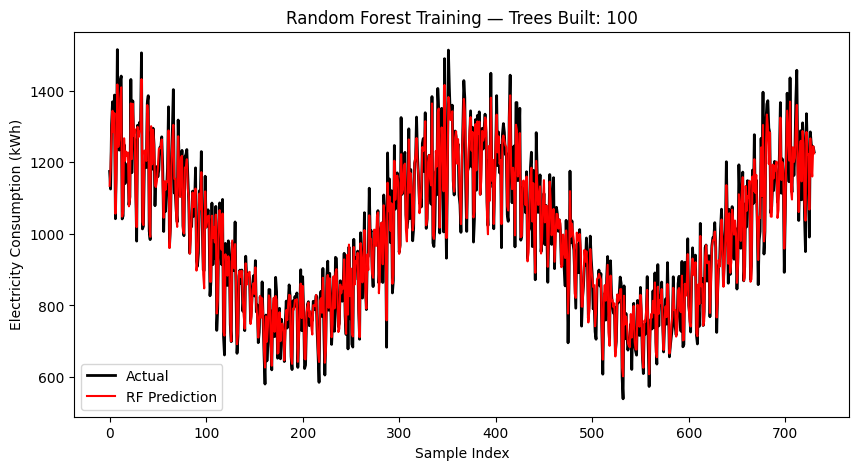

In [14]:
#RANDON FOREST ANIMATION FOR ELECTRICITY

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.ensemble import RandomForestRegressor

# =====================================================
# LOAD DATA
# =====================================================
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')

# =====================================================
# FIX: ADD TIME-BASED FEATURES FIRST
# =====================================================
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# =====================================================
# ELECTRICITY FEATURE SET (NO HDD)
# =====================================================
features_energy = [
    "Mean_Temp_C",
    "visitors_per_day",
    "solar_kwh_m2_day",
    "CDD_18",
    "month",
    "day_of_week",
    "is_weekend"
]

# Ensure all columns exist
missing = [f for f in features_energy if f not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# Feature matrix & target
X = df[features_energy]
y = df["site_energy_kwh_daily"]

# =====================================================
# RANDOM FOREST WARM-START INCREMENTAL TRAINING
# =====================================================
n_trees = 100  # number of animation frames

rf = RandomForestRegressor(
    n_estimators=1,
    warm_start=True,
    max_depth=15,
    random_state=42
)

predictions_over_time = []

# Build the forest one tree at a time
for i in range(1, n_trees + 1):
    rf.n_estimators = i
    rf.fit(X, y)
    preds = rf.predict(X)
    predictions_over_time.append(preds)

# =====================================================
# ANIMATION SETUP
# =====================================================
fig, ax = plt.subplots(figsize=(10,5))

line_actual, = ax.plot(y.values, label="Actual", color="black", linewidth=2)
line_pred, = ax.plot([], [], label="RF Prediction", color="red")

ax.set_title("Random Forest Learning Animation")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Electricity Consumption (kWh)")
ax.legend()

def update(frame):
    line_pred.set_data(range(len(y)), predictions_over_time[frame])
    ax.set_ylim(
        min(y.min(), predictions_over_time[frame].min()) - 50,
        max(y.max(), predictions_over_time[frame].max()) + 50
    )
    ax.set_title(f"Random Forest Training — Trees Built: {frame+1}")
    return line_pred,

ani = FuncAnimation(fig, update, frames=n_trees, interval=120)

# =====================================================
# SAVE ANIMATION
# =====================================================
ani.save("/content/drive/MyDrive/EnergyPrediction_LSE.gif", writer="ffmpeg")

print("Animation saved as /mnt/data/rf_learning_electricity.gif")
plt.show()


Animation saved as /mnt/data/rf_learning_gas.gif


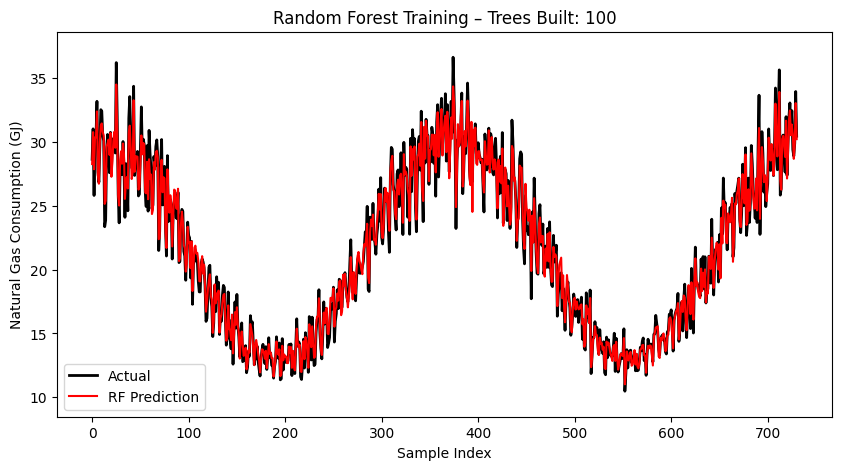

In [15]:
#GAS ANIMATION RF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.ensemble import RandomForestRegressor

# =====================================================
# LOAD DATA
# =====================================================
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')

# =====================================================
# FIX: ADD TIME-BASED FEATURES FIRST
# =====================================================
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# =====================================================
# NATURAL GAS FEATURE SET (NO CDD)
# =====================================================
features_gas = [
    "Mean_Temp_C",
    "visitors_per_day",
    "solar_kwh_m2_day",
    "HDD_18",        # <-- Gas uses HDD instead of CDD
    "month",
    "day_of_week",
    "is_weekend"
]

# Ensure all columns exist
missing = [f for f in features_gas if f not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# Feature matrix & target
X = df[features_gas]
y = df["Natural_Gas_Use_GJ"]

# =====================================================
# RANDOM FOREST WARM-START INCREMENTAL TRAINING
# =====================================================
n_trees = 100  # number of animation frames

rf = RandomForestRegressor(
    n_estimators=1,
    warm_start=True,
    max_depth=15,
    random_state=42
)

predictions_over_time = []

# Build the forest one tree at a time
for i in range(1, n_trees + 1):
    rf.n_estimators = i
    rf.fit(X, y)
    preds = rf.predict(X)
    predictions_over_time.append(preds)

# =====================================================
# ANIMATION SETUP
# =====================================================
fig, ax = plt.subplots(figsize=(10,5))

line_actual, = ax.plot(y.values, label="Actual", color="black", linewidth=2)
line_pred, = ax.plot([], [], label="RF Prediction", color="red")

ax.set_title("Random Forest Learning Animation – Natural Gas")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Natural Gas Consumption (GJ)")
ax.legend()

def update(frame):
    line_pred.set_data(range(len(y)), predictions_over_time[frame])
    ax.set_ylim(
        min(y.min(), predictions_over_time[frame].min()) - 2,
        max(y.max(), predictions_over_time[frame].max()) + 2
    )
    ax.set_title(f"Random Forest Training – Trees Built: {frame+1}")
    return line_pred,

ani = FuncAnimation(fig, update, frames=n_trees, interval=120)

# =====================================================
# SAVE ANIMATION
# =====================================================
ani.save("/content/drive/MyDrive/EnergyPrediction_LSE.gif", writer="ffmpeg")

print("Animation saved as /mnt/data/rf_learning_gas.gif")
plt.show()




===== ELECTRICITY MODEL COMPARISON =====
               Model        MAE        RMSE        R²
0      Random Forest  78.009615   99.088343  0.788012
1            XGBoost  78.246013  104.743477  0.763124
2  Gradient Boosting  81.762862  105.022513  0.761860
3  Linear Regression  95.588054  120.567063  0.686148


===== NATURAL GAS MODEL COMPARISON =====
               Model       MAE      RMSE        R²
0      Random Forest  1.501751  1.885482  0.912927
2  Gradient Boosting  1.576420  2.023761  0.899687
1            XGBoost  1.624150  2.070558  0.894994
3  Linear Regression  2.474473  3.100628  0.764528


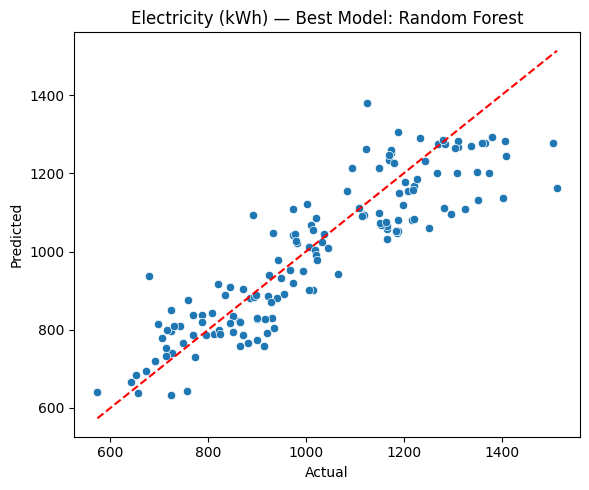

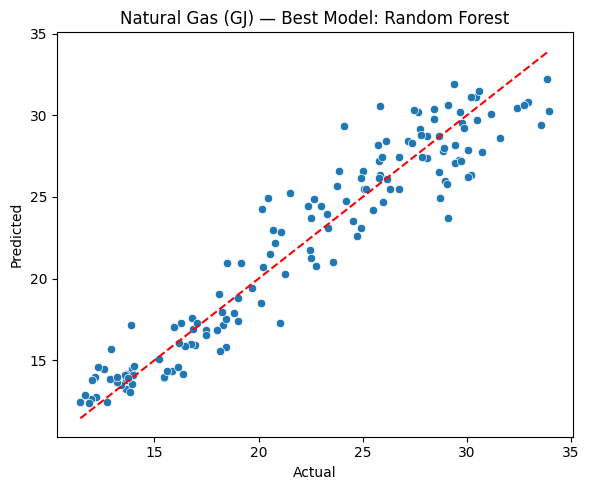

In [16]:
# COMPARE MULTIPLE ML MODELS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
df = pd.read_excel('/content/drive/MyDrive/EnergyPrediction_LSE/Data_Energy_Temperature.xlsx')

# ---------------------------------------------------
# TIME-BASED FEATURE ENGINEERING
# ---------------------------------------------------
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df = df.drop(columns=['Date'])

# ---------------------------------------------------
# FEATURE SETS
# ---------------------------------------------------

# Electricity model NO HDD
features_energy = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day', 'CDD_18', 'relative_humidity',
    'month', 'day_of_week', 'is_weekend'
]

# Gas model NO CDD
features_gas = [
    'Mean_Temp_C', 'visitors_per_day', 'solar_kwh_m2_day', 'HDD_18','relative_humidity',
    'month', 'day_of_week', 'is_weekend'
]

X_energy = df[features_energy]
X_gas = df[features_gas]

y_energy = df['site_energy_kwh_daily']
y_gas = df['Natural_Gas_Use_GJ']

# ---------------------------------------------------
# TRAIN/TEST SPLIT
# ---------------------------------------------------
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_energy, y_energy, test_size=0.2, random_state=42
)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gas, y_gas, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# MODEL DEFINITIONS
# ---------------------------------------------------
def get_models():
    return {
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42),
        "XGBoost": xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4),
        "Linear Regression": LinearRegression()
    }

# ---------------------------------------------------
# MODEL TRAINING & EVALUATION
# ---------------------------------------------------
def evaluate_models(X_train, X_test, y_train, y_test):

    models = get_models()
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, pred)

        results.append([name, mae, rmse, r2, model])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²", "Model_Object"])
    results_df = results_df.sort_values(by="RMSE")  # Rank by lowest RMSE

    return results_df

# ---------------------------------------------------
# RUN COMPARISON
# ---------------------------------------------------
print("\n\n===== ELECTRICITY MODEL COMPARISON =====")
results_energy = evaluate_models(X_train_e, X_test_e, y_train_e, y_test_e)
print(results_energy[["Model", "MAE", "RMSE", "R²"]])

print("\n\n===== NATURAL GAS MODEL COMPARISON =====")
results_gas = evaluate_models(X_train_g, X_test_g, y_train_g, y_test_g)
print(results_gas[["Model", "MAE", "RMSE", "R²"]])

# ---------------------------------------------------
# PLOT BEST MODEL RESULTS
# ---------------------------------------------------
def plot_best(results_df, X_test, y_test, title):

    best_model = results_df.iloc[0]["Model_Object"]
    best_name = results_df.iloc[0]["Model"]

    pred = best_model.predict(X_test)

    # Predicted vs Actual
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=pred)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{title} — Best Model: {best_name}")
    plt.tight_layout()
    plt.show()

# Show plots
plot_best(results_energy, X_test_e, y_test_e, "Electricity (kWh)")
plot_best(results_gas, X_test_g, y_test_g, "Natural Gas (GJ)")


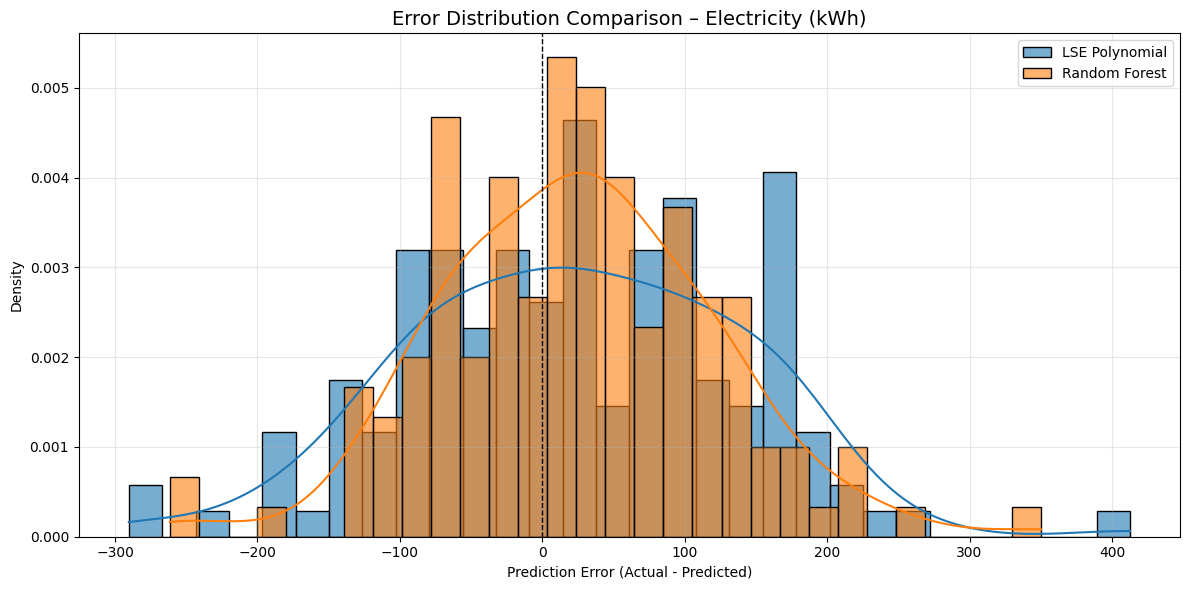

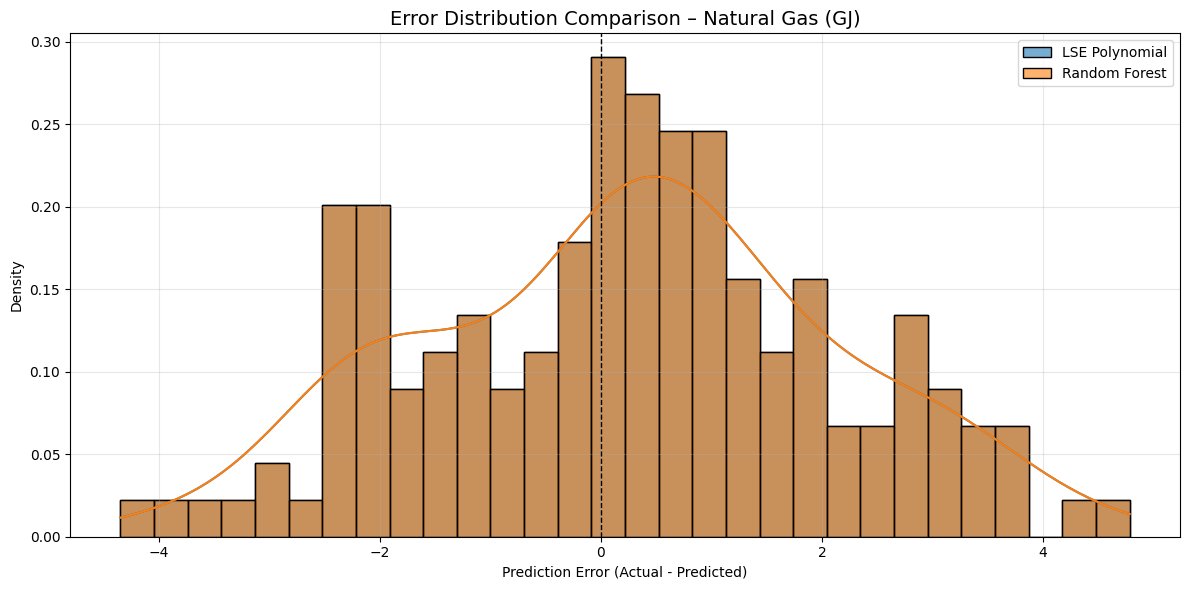

In [17]:
# ===============================================
# ERROR DISTRIBUTION COMPARISON (LSE vs RF)
# ===============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------------------------
# Compute residuals (Errors = Actual - Predicted)
# -----------------------------------------------
err_energy_lse = y_test_e - lse_pred_energy
err_energy_rf  = y_test_e - rf_pred_energy

err_gas_lse = y_test_g - lse_pred_gas
err_gas_rf  = y_test_g - lse_pred_gas

# -----------------------------------------------
# PLOTTING FUNCTION
# -----------------------------------------------
def error_distribution_plot(err_lse, err_rf, title):
    plt.figure(figsize=(12,6))

    sns.histplot(err_lse, kde=True, bins=30, stat="density", label="LSE Polynomial", alpha=0.6)
    sns.histplot(err_rf,  kde=True, bins=30, stat="density", label="Random Forest", alpha=0.6)

    plt.axvline(0, color='black', linewidth=1, linestyle='--')
    plt.title(f"Error Distribution Comparison – {title}", fontsize=14)
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -----------------------------------------------
# GENERATE PLOTS
# -----------------------------------------------
error_distribution_plot(err_energy_lse, err_energy_rf, "Electricity (kWh)")
error_distribution_plot(err_gas_lse, err_gas_rf, "Natural Gas (GJ)")
